In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report
)


Load Dataset

In [2]:
# Load dataset from data folder
df = pd.read_csv("data/processed_diabetes_dataset .csv")

df.head(5)



,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_std,bmi_std,HbA1c_level_std,blood_glucose_level_std,age_group_Adult,age_group_Middle-aged,age_group_Senior,age_group_Young
0,0,80.0,0,1,4,25.19,6.6,140,0,1.700377,-0.236198,1.064593,0.145124,0,0,1,0
1,0,54.0,0,0,0,27.32,6.6,80,0,0.549140,0.200062,1.064593,-1.552541,0,1,0,0
2,1,28.0,0,0,4,27.32,5.7,158,0,-0.602096,0.200062,0.202606,0.654423,1,0,0,0
3,0,36.0,0,0,1,23.45,5.0,155,0,-0.247870,-0.592579,-0.467828,0.569540,1,0,0,0
4,1,76.0,1,1,1,20.14,4.8,155,0,1.523264,-1.270523,-0.659380,0.569540,0,0,1,0


Split Features and Labels

In [26]:
# Feature columns (PC1, PC2) and target variable (diabetes)
y = df["diabetes"]
X = df.drop(columns=["diabetes"])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)


Training data shape: (137427, 16)
Test data shape: (34357, 16)


Train Baseline Random Forest

In [23]:
baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_rf.fit(X_train, y_train)

# Predict
y_pred_base = baseline_rf.predict(X_test)

# Metrics
baseline_accuracy = accuracy_score(y_test, y_pred_base)
baseline_f1 = f1_score(y_test, y_pred_base, average='macro')

print("Baseline Random Forest Accuracy:", baseline_accuracy)
print("Baseline F1 Score:", baseline_f1)


Baseline Random Forest Accuracy: 0.9930145239689147
Baseline F1 Score: 0.9930141859178131


Cross Validation (Baseline Model)

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(baseline_rf, X, y, cv=cv, scoring='accuracy')
print("Cross Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))


Cross Validation Accuracy Scores: [0.99371307 0.99313095 0.99278167 0.9933929  0.99313075]
Mean CV Accuracy: 0.9932298694923809


Hyperparameter Tuning (GridSearchCV)

In [28]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
best_rf = grid.best_estimator_


Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


Evaluate Best Model

In [29]:
y_pred_best = best_rf.predict(X_test)

print("Best Model Accuracy:", accuracy_score(y_test, y_pred_best))
print("Best Model F1 Score:", f1_score(y_test, y_pred_best, average='macro'))

# Classification Report
print(classification_report(y_test, y_pred_best))


Best Model Accuracy: 0.992868993218267
Best Model F1 Score: 0.9928686335335895
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     17179
           1       0.99      1.00      0.99     17178

    accuracy                           0.99     34357
   macro avg       0.99      0.99      0.99     34357
weighted avg       0.99      0.99      0.99     34357



Confusion Matrix Plot

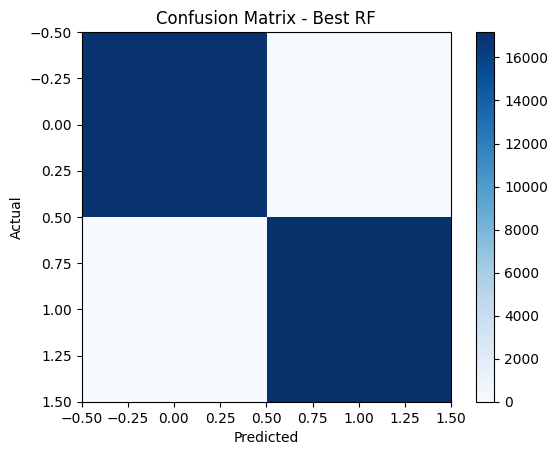

In [30]:
cm = confusion_matrix(y_test, y_pred_best)
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - Best RF")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("results/figures/Confusion Matrix.png", dpi=300)

plt.show()


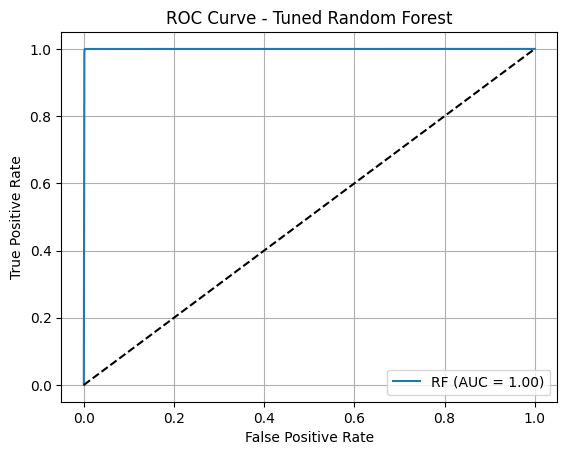

In [31]:
y_prob_best = best_rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc = roc_auc_score(y_test, y_prob_best)

plt.figure()
plt.plot(fpr, tpr, label=f'RF (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Tuned Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()

plt.savefig("results/figures/ROC_Curve.png", dpi=300)

plt.show()


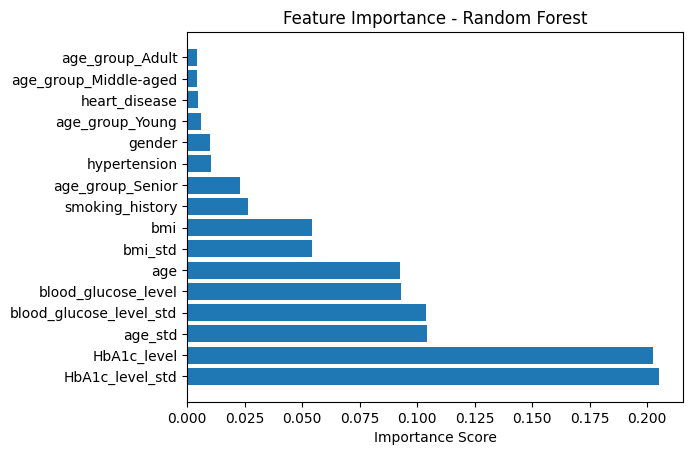

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')

plt.savefig("results/figures/feature_importance_best_rf.png", dpi=300)

plt.show()



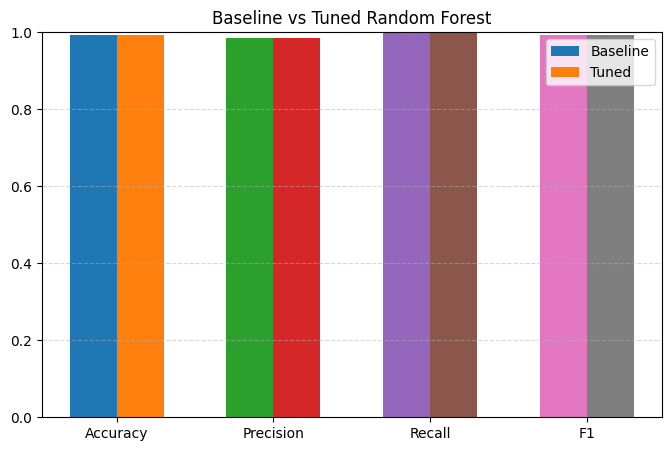

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'],
    'Baseline': [
        accuracy_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_base, zero_division=0),
        recall_score(y_test, y_pred_base, zero_division=0),
        f1_score(y_test, y_pred_base, average='macro')
    ],
    'Tuned': [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best, zero_division=0),
        recall_score(y_test, y_pred_best, zero_division=0),
        f1_score(y_test, y_pred_best, average='macro')
    ]
})

metrics_melted = metrics.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(8,5))
plt.title('Baseline vs Tuned Random Forest')
for metric in range(len(metrics)):
    plt.bar([metric-0.15],[metrics['Baseline'][metric]],width=0.3,label='Baseline' if metric==0 else "")
    plt.bar([metric+0.15],[metrics['Tuned'][metric]],width=0.3,label='Tuned' if metric==0 else "")
plt.xticks(range(len(metrics)),metrics['Metric'])
plt.ylim(0,1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig("results/figures/baseline_vs_tuned_comparison.png", dpi=300)

plt.show()



Results to Results Folder

In [34]:
# Save metrics
results = {
    "baseline_accuracy": baseline_accuracy,
    "baseline_f1": baseline_f1,
    "best_params": grid.best_params_
}

pd.DataFrame([results]).to_csv("results/metrics/metrics_summary.csv", index=False)
print("Results saved in 'results/'")


import joblib
import os

os.makedirs('results/models', exist_ok=True)
joblib.dump(best_rf, 'results/models/random_forest_model.pkl')
print("Model saved successfully!")



Results saved in 'results/'
Model saved successfully!
